# Lesson 13 — Hypothesis testing: p-values, errors & power

*Part 2 · Lesson 13 of 20  ·  data: simulation on a known population*

**←** [Flagship — Confidence intervals](12-confidence-intervals.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 14: Inference for proportions (one & two)](14-inference-proportions.ipynb) **→**

**Same idea, another way:**  [Another dataset →](13-hypothesis-testing~another-dataset.ipynb)  ·  [The code behind it →](13-hypothesis-testing~the-code.ipynb)

The confidence-interval flagship asked *"what range of values is plausible for the truth?"* A
**hypothesis test** asks a sharper, yes/no question: *"is this specific claim about the truth
believable, or is the data too surprising for it?"*

The whole machine runs on one idea you can **see** rather than memorize: pretend the boring claim is
true, simulate the world it describes thousands of times, and check how often that pretend world
coughs up data as extreme as what you actually got. That fraction is the famous **p-value**. Because
we'll use the **Ames housing** file as a *known* population, we can do something a real analyst never
can — peek at the true answer and watch the test get it right (and sometimes wrong). Run each grey
cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats        # one-sample t-test lives here
sl.use_course_style()

AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'
ames = sl.load_csv('ames.csv', url=AMES_URL)

# Treat the WHOLE file as the population, exactly like the confidence-interval flagship.
population = ames['area'].dropna().to_numpy()    # above-grade living area, sq ft
MU = population.mean()                            # the TRUE mean — we get to know it!
SIGMA = population.std(ddof=0)                    # the TRUE population standard deviation
N_POP = len(population)
print(f'Population: {N_POP:,} Ames homes')
print(f'TRUE mean  MU    = {MU:.1f} sq ft   <- normally hidden; here we can peek')
print(f'TRUE stdev SIGMA = {SIGMA:.1f} sq ft')

Population: 2,930 Ames homes
TRUE mean  MU    = 1499.7 sq ft   <- normally hidden; here we can peek
TRUE stdev SIGMA = 505.4 sq ft


## 1) The setup: a claim, and a way to doubt it

Suppose a local realtor insists:

> *"The typical Ames home has **1,400 square feet** of living space."*

We don't get to see all 2,930 homes — we get a **sample**. From that sample we'll decide whether 1,400
is believable. Every hypothesis test names **two** competing statements:

- **Null hypothesis $H_0$** — the "nothing special / status quo" claim we'll try to *disprove*. Here
  $H_0:\ \mu = 1400$. The null is always an *equality* — a single, precise number to simulate.
- **Alternative hypothesis $H_a$** — what we suspect instead. We'll use the **two-sided**
  $H_a:\ \mu \neq 1400$ (the true mean is *different*, in either direction).

A test never *proves* $H_0$. Like a courtroom, it presumes the null ("innocent") and asks whether the
evidence is strong enough to **reject** it ("guilty beyond reasonable doubt"). Failing to reject is
*"not enough evidence,"* never *"proven innocent."*

In [2]:
H0_value = 1400.0      # the realtor's claim about the true mean (sq ft)

rng = np.random.default_rng(13)   # change this seed to draw a different sample
n = 40                            # our sample size

sample = rng.choice(population, size=n, replace=False)
xbar = sample.mean()
s = sample.std(ddof=1)
print(f'Our one sample of {n} homes:')
print(f'  sample mean  xbar = {xbar:.1f} sq ft')
print(f'  sample stdev s    = {s:.1f} sq ft')
print(f'\nThe claim says mu = {H0_value:.0f}. Our sample came out {xbar - H0_value:+.1f} sq ft away.')
print('Is that gap real evidence, or just the luck of which 40 homes we happened to grab?')

Our one sample of 40 homes:
  sample mean  xbar = 1528.2 sq ft
  sample stdev s    = 450.9 sq ft

The claim says mu = 1400. Our sample came out +128.2 sq ft away.
Is that gap real evidence, or just the luck of which 40 homes we happened to grab?


## 2) The test statistic: turn the gap into a standardized distance

A raw gap of "+128 sq ft" is hard to judge — is that a lot? It depends on how much sample means
*naturally* wobble. We rescale the gap by the **standard error** $s/\sqrt{n}$ (the typical wobble of
$\bar{x}$, from the estimation lesson) to get the **t statistic**:

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

- **The math:** how many standard errors the sample mean sits from the claimed value $\mu_0$.
- **The meaning:** a universal "surprise ruler." $t = 0$ means the sample landed exactly on the claim;
  $|t| = 2$ means "about two standard errors away" — already fairly far.
- **The interpretation:** big $|t|$ = the data and the claim disagree a lot; small $|t|$ = they get
  along fine.

In [3]:
se = s / np.sqrt(n)                       # standard error of the mean
t_obs = (xbar - H0_value) / se
print(f'standard error  s/sqrt(n) = {se:.1f} sq ft')
print(f'observed t statistic      = {t_obs:.3f}')
print(f'\nOur sample mean sits about {t_obs:.2f} standard errors above the claimed 1,400 sq ft.')

standard error  s/sqrt(n) = 71.3 sq ft
observed t statistic      = 1.798

Our sample mean sits about 1.80 standard errors above the claimed 1,400 sq ft.


## 3) The p-value, built by simulating the null world

Here's the heart of the whole lesson — and we'll **simulate it before trusting any formula.**

**Question:** *if the realtor were right ($\mu = 1400$), how often would pure sampling luck hand us a $t$
at least as extreme as the one we saw?*

To answer it we need a **"null world"**: a population whose true mean really is 1,400. We can build one
by sliding our entire known population sideways so its mean lands exactly on 1,400 — same shape, same
spread, just recentered. Then we draw thousands of samples *from that null world*, compute $t$ each
time, and collect them into the **null distribution** of the statistic. The **p-value** is simply the
share of those simulated $t$'s that are as far from 0 as ours (in *either* direction, because $H_a$ is
two-sided).

In [4]:
# A population whose true mean IS the null value (same shape, just shifted).
null_population = population - MU + H0_value
print(f'null world mean = {null_population.mean():.1f} sq ft  (exactly the claim, by construction)')

# Draw many samples FROM THE NULL WORLD and record the t statistic each time.
n_sims = 40000
null_ts = np.empty(n_sims)
for i in range(n_sims):
    s_null = rng.choice(null_population, size=n, replace=False)
    null_ts[i] = (s_null.mean() - H0_value) / (s_null.std(ddof=1) / np.sqrt(n))

# p-value = fraction of the null world at least as extreme as what we observed.
p_sim = np.mean(np.abs(null_ts) >= np.abs(t_obs))
print(f'\nSimulated two-sided p-value = {p_sim:.4f}')
print(f'(That is the share of {n_sims:,} make-believe samples with |t| >= {abs(t_obs):.2f}.)')

null world mean = 1400.0 sq ft  (exactly the claim, by construction)



Simulated two-sided p-value = 0.0823
(That is the share of 40,000 make-believe samples with |t| >= 1.80.)


### See it: where does our sample fall in the null world?

The histogram is the null distribution of $t$ — every value the statistic *could* take if the claim
were true. The red lines mark $\pm|t_{obs}|$; the shaded tails are the p-value. If our $t$ sits deep in
a tail, the null world rarely produces data like ours, and we start to doubt the claim.

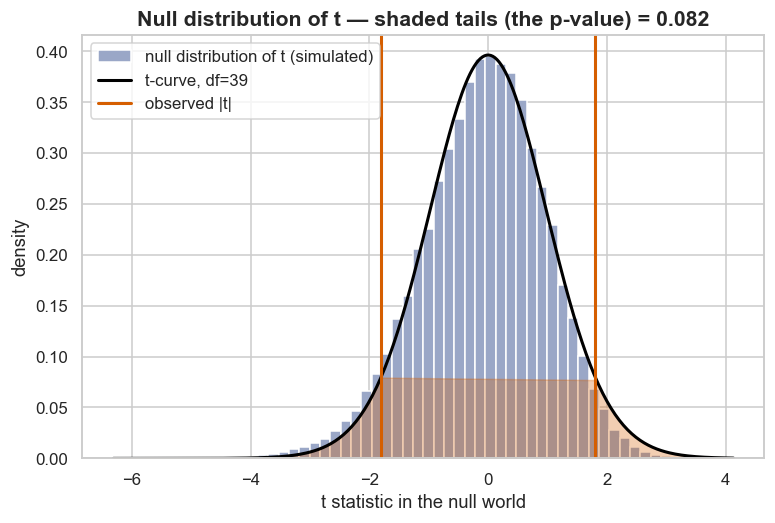

In [5]:
fig, ax = plt.subplots()
ax.hist(null_ts, bins=60, color='#9aa7c7', edgecolor='white', density=True,
        label='null distribution of t (simulated)')

# overlay the textbook t-curve it should match
xs = np.linspace(null_ts.min(), null_ts.max(), 300)
ax.plot(xs, stats.t.pdf(xs, df=n - 1), color='black', lw=2, label=f't-curve, df={n-1}')

for sign in (-1, 1):
    ax.axvline(sign * abs(t_obs), color='#D55E00', lw=2,
               label='observed |t|' if sign == 1 else None)
# shade the two tails (the p-value) on the simulated curve
tail = xs[np.abs(xs) >= abs(t_obs)]
ax.fill_between(tail, stats.t.pdf(tail, df=n - 1), color='#D55E00', alpha=0.30)

ax.set_xlabel('t statistic in the null world'); ax.set_ylabel('density')
ax.set_title(f'Null distribution of t — shaded tails (the p-value) = {p_sim:.3f}')
ax.legend(); plt.show()

## 4) The formula confirms the simulation: `scipy.stats.ttest_1samp`

The simulation taught us *what a p-value is*. The textbook one-sample **t-test** gives the same number
in one line — it just reads the tail area off the smooth $t$-curve (the black line above) instead of
counting simulated samples. They should agree closely.

In [6]:
result = stats.ttest_1samp(sample, popmean=H0_value, alternative='two-sided')
print(f'simulated p-value (null world) = {p_sim:.4f}')
print(f'scipy ttest_1samp p-value      = {result.pvalue:.4f}')
print(f'scipy t statistic              = {result.statistic:.3f}   (matches ours: {t_obs:.3f})')
print('\nThe formula and the simulation agree — they are two views of the same idea.')

simulated p-value (null world) = 0.0823
scipy ttest_1samp p-value      = 0.0799
scipy t statistic              = 1.798   (matches ours: 1.798)

The formula and the simulation agree — they are two views of the same idea.


## 5) The decision rule, and reading a p-value correctly

Before looking at the data, you pick a **significance level $\alpha$** — the risk you're willing to
take of a false alarm. The convention is $\alpha = 0.05$. The rule:

- **$p \le \alpha$** → **reject $H_0$** (the data is too surprising for the null; call it *statistically
  significant*).
- **$p > \alpha$** → **fail to reject $H_0$** (not enough evidence; the null survives, *un*-proven).

What a p-value **is:** *if $H_0$ were true, the probability of data at least this extreme.* It measures
**surprise under the null.**

What a p-value is **NOT** — the three classic traps:

- ❌ It is **not** "the probability that $H_0$ is true." (The data is random; $H_0$ is just true or
  false. $p$ is $P(\text{data}\mid H_0)$, never $P(H_0\mid \text{data})$.)
- ❌ It is **not** an **effect size**. A tiny, useless difference can have a microscopic p-value if $n$
  is huge. Significant $\neq$ large or important.
- ❌ "Fail to reject" is **not** "proved $H_0$." Absence of evidence isn't evidence of absence.

In [7]:
alpha = 0.05
decision = 'REJECT H0' if result.pvalue <= alpha else 'FAIL TO REJECT H0'
print(f'p-value = {result.pvalue:.4f}   alpha = {alpha}')
print(f'Decision: {decision}')
print(f'\nPlain English: with p = {result.pvalue:.3f} > 0.05, a sample mean {xbar - H0_value:+.0f} sq ft')
print('from the claim is NOT surprising enough to rule out mu = 1,400. The claim survives this test.')
print(f'(We happen to know the truth is {MU:.0f} — so failing to reject 1,400 was an understandable miss.)')

p-value = 0.0799   alpha = 0.05
Decision: FAIL TO REJECT H0

Plain English: with p = 0.080 > 0.05, a sample mean +128 sq ft
from the claim is NOT surprising enough to rule out mu = 1,400. The claim survives this test.
(We happen to know the truth is 1500 — so failing to reject 1,400 was an understandable miss.)


## 6) Type I and Type II errors — the two ways to be wrong

A test makes a yes/no call about an unknown truth, so there are exactly **two** ways to blunder:

| | $H_0$ is really **true** | $H_0$ is really **false** |
|---|---|---|
| **We reject $H_0$** | ❌ **Type I error** (false alarm) | ✅ correct (a "hit") |
| **We fail to reject** | ✅ correct | ❌ **Type II error** (a miss) |

- **Type I error** = rejecting a *true* null (crying wolf). Its long-run rate **is** $\alpha$ — that's
  what choosing $\alpha = 0.05$ *means*: a 5% false-alarm rate when the null is true.
- **Type II error** = failing to detect a *real* effect. Its rate is called **$\beta$**.
- **Power $= 1 - \beta$** = the chance of correctly catching a real effect.

Because we own the population, we can **measure** these rates by brute force. First the Type I rate:
make $H_0$ *true* by testing the real mean, run thousands of tests, and count false alarms.

In [8]:
def reject_rate(test_population, h0, n=50, alpha=0.05, trials=4000, seed=1):
    # Fraction of t-tests that REJECT H0: mu = h0. We sample WITH replacement, treating
    # the file as an effectively infinite super-population — so n is not capped at 2,930
    # and there is no finite-population correction distorting the standard error.
    r = np.random.default_rng(seed)
    rejects = 0
    for _ in range(trials):
        s = r.choice(test_population, size=n, replace=True)
        if stats.ttest_1samp(s, h0).pvalue <= alpha:
            rejects += 1
    return rejects / trials

# Type I: H0 is TRUE because we test the real population mean MU.
type1 = reject_rate(population, h0=MU, n=50, alpha=0.05)
print(f'Type I error rate (testing the TRUE mean, alpha=0.05): {type1:.3f}')
print(f'It lands near alpha = 0.05 — exactly as the theory promises.')

Type I error rate (testing the TRUE mean, alpha=0.05): 0.057
It lands near alpha = 0.05 — exactly as the theory promises.


The false-alarm rate comes out right around **0.05** — the 5% we signed up for. Change `alpha` to `0.01`
and you'd see it drop toward 0.01. **You control your Type I rate directly: it is $\alpha$.**

## 7) Power: catching a real effect — built as a simulated curve

Power is the flip side: when $H_0$ is genuinely *false*, how often does the test actually notice? We
create a *false* null by testing a wrong value $\mu_0 = \mu - \text{effect}$, so the true mean is
"effect" sq ft away from the claim. Power should climb as the **effect size** grows (a bigger lie is
easier to catch).

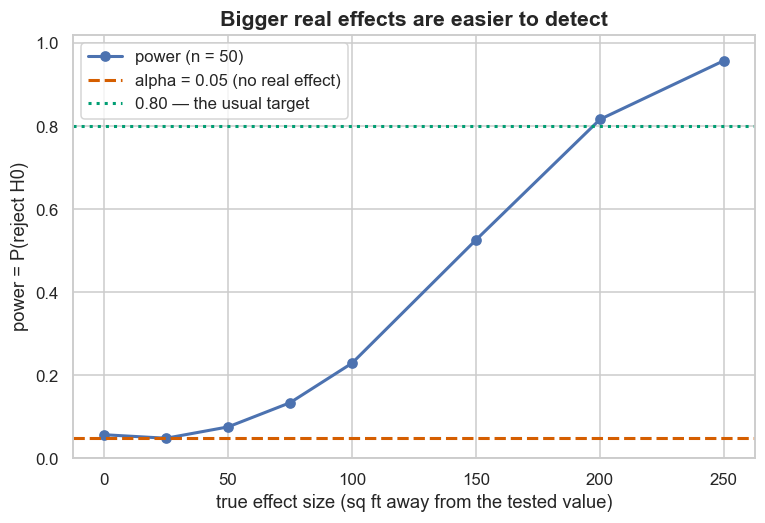

  effect =   0 sq ft  ->  power = 0.057
  effect =  25 sq ft  ->  power = 0.049
  effect =  50 sq ft  ->  power = 0.076
  effect =  75 sq ft  ->  power = 0.134
  effect = 100 sq ft  ->  power = 0.229
  effect = 150 sq ft  ->  power = 0.526
  effect = 200 sq ft  ->  power = 0.817
  effect = 250 sq ft  ->  power = 0.958


In [9]:
effects = np.array([0, 25, 50, 75, 100, 150, 200, 250])   # how far the truth sits from the tested H0
power_by_effect = [reject_rate(population, h0=MU - e, n=50, alpha=0.05) for e in effects]

fig, ax = plt.subplots()
ax.plot(effects, power_by_effect, 'o-', color='#4c72b0', lw=2, label='power (n = 50)')
ax.axhline(0.05, color='#D55E00', ls='--', lw=2, label='alpha = 0.05 (no real effect)')
ax.axhline(0.80, color='#009E73', ls=':', lw=2, label='0.80 — the usual target')
ax.set_xlabel('true effect size (sq ft away from the tested value)')
ax.set_ylabel('power = P(reject H0)')
ax.set_title('Bigger real effects are easier to detect')
ax.set_ylim(0, 1.02); ax.legend(); plt.show()

for e, pw in zip(effects, power_by_effect):
    print(f'  effect = {e:3d} sq ft  ->  power = {pw:.3f}')

At an effect of **0** the curve sits at $\alpha = 0.05$ (there's *nothing* to detect, so every rejection
is a false alarm — that's the Type I rate again). As the true mean drifts further from the claim, power
rises toward 1: a whopping lie is almost always caught.

### The other lever: sample size

The second way to buy power is **more data**. A bigger $n$ shrinks the standard error, so even a modest
effect becomes detectable. Let's hold the effect fixed at a stubborn 75 sq ft and grow $n$.

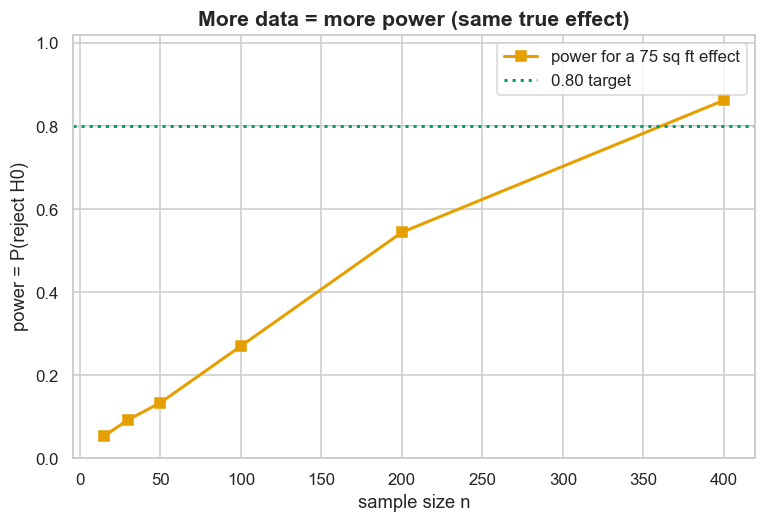

  n =  15  ->  power = 0.053
  n =  30  ->  power = 0.093
  n =  50  ->  power = 0.134
  n = 100  ->  power = 0.271
  n = 200  ->  power = 0.544
  n = 400  ->  power = 0.863

Four levers set power: effect size, sample size n, alpha, and the spread of the data.


In [10]:
sizes = [15, 30, 50, 100, 200, 400]
fixed_effect = 75
power_by_n = [reject_rate(population, h0=MU - fixed_effect, n=nn, alpha=0.05) for nn in sizes]

fig, ax = plt.subplots()
ax.plot(sizes, power_by_n, 's-', color='#E69F00', lw=2, label=f'power for a {fixed_effect} sq ft effect')
ax.axhline(0.80, color='#009E73', ls=':', lw=2, label='0.80 target')
ax.set_xlabel('sample size n'); ax.set_ylabel('power = P(reject H0)')
ax.set_title('More data = more power (same true effect)')
ax.set_ylim(0, 1.02); ax.legend(); plt.show()

for nn, pw in zip(sizes, power_by_n):
    print(f'  n = {nn:3d}  ->  power = {pw:.3f}')
print('\nFour levers set power: effect size, sample size n, alpha, and the spread of the data.')

## 8) The duality: a confidence interval *is* a test

Hypothesis tests and the confidence intervals from the flagship are two faces of one coin:

> A value $\mu_0$ falls **outside** the 95% confidence interval **exactly when** a two-sided test at
> $\alpha = 0.05$ would **reject** it.

So a CI is a whole batch of tests at once: it lists *every* null value the data would *not* reject. Let's
confirm it on our sample — for several candidate claims, "rejected at 5%?" should be the mirror image of
"outside the 95% CI?"

In [11]:
ci = stats.ttest_1samp(sample, H0_value).confidence_interval(0.95)
print(f'95% confidence interval for the true mean: ({ci.low:.1f}, {ci.high:.1f}) sq ft\n')
print(f"{'claim mu0':>10} {'p-value':>9} {'reject@5%?':>11} {'inside 95% CI?':>15}")
for mu0 in [1300, 1400, 1450, 1500, 1600, 1700]:
    p = stats.ttest_1samp(sample, mu0).pvalue
    reject = p <= 0.05
    inside = ci.low <= mu0 <= ci.high
    flag = '  <- mismatch?' if reject == inside else ''
    print(f"{mu0:>10} {p:>9.3f} {str(reject):>11} {str(inside):>15}{flag}")
print('\n"reject@5%" is always the OPPOSITE of "inside the 95% CI" — that is the duality.')

95% confidence interval for the true mean: (1384.0, 1672.4) sq ft

 claim mu0   p-value  reject@5%?  inside 95% CI?
      1300     0.003        True           False
      1400     0.080       False            True
      1450     0.279       False            True
      1500     0.695       False            True
      1600     0.320       False            True
      1700     0.021        True           False

"reject@5%" is always the OPPOSITE of "inside the 95% CI" — that is the duality.


Notice **1,400 is inside the interval** (so we fail to reject it — agreeing with section 5), and so is
the **true mean we secretly know**. The interval hands you the test result for *every* possible claim in
one shot.

## 9) Two cautions before you go testing everything

**Statistical vs. practical significance.** With enough data, *any* tiny difference becomes
"significant." Imagine the true mean were just 5 sq ft from the claim — a difference nobody would care
about. With a giant sample the test still rejects, p-value and all. **A small p-value says "this gap is
probably real," not "this gap is big or important."** Always report the *effect size* (and ideally a CI)
alongside the p-value. Watch it happen:

In [12]:
# A trivially small TRUE effect (5 sq ft), tested at two very different sample sizes.
tiny_effect_pop = population            # true mean = MU
huge_n = 20000
big = reject_rate(tiny_effect_pop, h0=MU - 5, n=huge_n, alpha=0.05, trials=2000)
small = reject_rate(tiny_effect_pop, h0=MU - 5, n=40, alpha=0.05, trials=2000)
print(f'A meaningless 5 sq ft effect:')
print(f'  with n = {huge_n:,}: rejected {big*100:.0f}% of the time  (huge n manufactures "significance")')
print(f'  with n = {40:,}: rejected {small*100:.0f}% of the time  (sensibly, near the {0.05*100:.0f}% false-alarm floor)')
print('\nSignificant is not the same as large. Report the size of the effect, not just the p-value.')

A meaningless 5 sq ft effect:
  with n = 20,000: rejected 29% of the time  (huge n manufactures "significance")
  with n = 40: rejected 6% of the time  (sensibly, near the 5% false-alarm floor)

Significant is not the same as large. Report the size of the effect, not just the p-value.


**Multiple testing.** If a *single* test at $\alpha = 0.05$ has a 5% false-alarm rate, then running
*many* tests on noise will turn up "significant" results by chance alone. Test 20 truly-null
hypotheses and you *expect* about one false positive. (This is the "green jelly beans cause acne"
problem.) Let's watch 20 honest-but-null tests and count the inevitable false alarms.

In [13]:
r = np.random.default_rng(4)
n_tests = 20
pvals = []
for _ in range(n_tests):
    s = r.choice(population, size=40, replace=False)   # H0: mu = MU is TRUE every time
    pvals.append(stats.ttest_1samp(s, MU).pvalue)
pvals = np.array(pvals)
false_alarms = int(np.sum(pvals <= 0.05))
print(f'Ran {n_tests} tests where H0 was TRUE every single time.')
print(f'"Significant" (p <= 0.05) results: {false_alarms}  (we expect about {0.05*n_tests:.0f} by pure chance)')
print('\nLowest p-value found:', f'{pvals.min():.3f}')
print('Hunt through enough true nulls and one will look "significant" — adjust alpha when testing many.')

Ran 20 tests where H0 was TRUE every single time.
"Significant" (p <= 0.05) results: 1  (we expect about 1 by pure chance)

Lowest p-value found: 0.027
Hunt through enough true nulls and one will look "significant" — adjust alpha when testing many.


## Now you try

Predict first, then change a number and re-run:

1. **Make the claim wronger.** In section 1, set `H0_value = 1300` (further from the true ~1500), re-run
   sections 1-5. Does the p-value go **up** or **down**? Does the decision flip to *reject*?
2. **Grow the sample.** Change `n = 40` to `n = 300` (keep `H0_value = 1400`). The same 1,400 claim is
   now tested against far more data — predict whether you'll reject it, then check. (This is statistical
   vs. practical significance in action.)
3. **One-sided test.** The realtor might only care if homes are *bigger* than claimed. Re-run section 4
   with `alternative='greater'`. How does the p-value compare to the two-sided one, and why roughly half?
4. **Re-roll luck.** Change `np.random.default_rng(13)` in section 1 to other seeds and re-run. Roughly
   how often does the test (wrongly) reject the true-ish claim of 1,400? Connect that to the Type I rate.

## What you learned

- A test pits a precise **null $H_0$** against an **alternative $H_a$**; you presume the null and ask
  whether the data is too surprising to keep it.
- The **test statistic** ($t = (\bar{x}-\mu_0)/(s/\sqrt{n})$) measures, in standard errors, how far the
  sample sits from the claim.
- The **p-value** is the share of a **simulated null world** at least as extreme as your data — and the
  textbook **t-test** (`scipy.stats.ttest_1samp`) reproduces it exactly.
- A p-value is **surprise under the null**, *not* the probability $H_0$ is true and *not* an effect
  size; **"fail to reject" never means "proven."**
- **Type I error** (false alarm) happens at rate **$\alpha$**; **Type II error** (a miss) at rate
  **$\beta$**, and **power $= 1-\beta$** rises with **effect size** and **sample size**.
- A **95% confidence interval** and a 5% two-sided test are **dual**: the interval is exactly the set of
  null values the test would *not* reject.
- Beware **statistical vs. practical significance** (big $n$ makes trivial effects "significant") and
  **multiple testing** (run enough tests and noise looks significant).

---

**← Previous:** [Flagship — Confidence intervals](12-confidence-intervals.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 14: Inference for proportions (one & two)](14-inference-proportions.ipynb)

**Same idea, another way:**  [Another dataset →](13-hypothesis-testing~another-dataset.ipynb)  ·  [The code behind it →](13-hypothesis-testing~the-code.ipynb)